<a href="https://colab.research.google.com/github/SabinPopa1/PMP/blob/main/Partial/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install hmmlearn

# Subiect 1

1.1 Drum cel mai probabil al agentului: [(7, 0), (7, 0), (7, 1), (7, 2), (8, 2)]
1.1 Log-probabilitatea drumului: -11.237665912517004
1.2 Drum cel mai probabil al agentului fără mutarea la stânga: [(7, 0), (7, 0), (7, 1), (7, 2), (8, 2)]
1.2 Log-probabilitatea drumului fără mutarea la stânga: -10.216014664985023


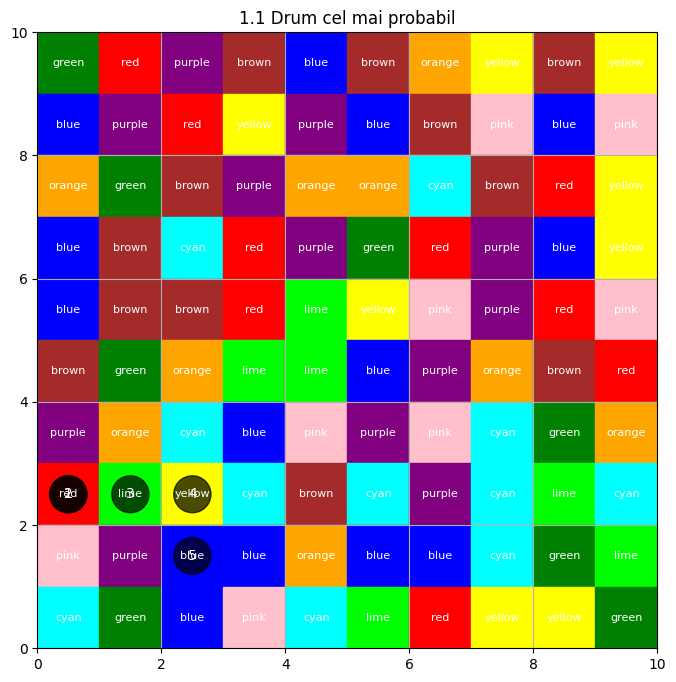

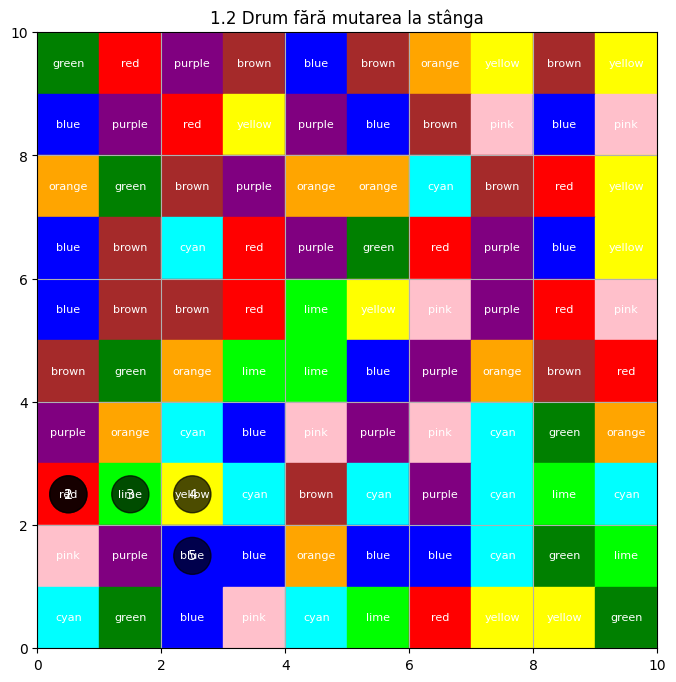

In [13]:
from hmmlearn import hmm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hmmlearn.hmm import CategoricalHMM

# Dimensiunea gridului
dimensiune_grid = (10, 10)

# Lista de culori predefinite
culori = [
    "red", "blue", "green", "yellow",
    "purple", "orange", "pink", "cyan",
    "brown", "lime"
]

# Citirea gridului
df = pd.read_csv('grid_culori.csv', header=None)
grid_culori = df.to_numpy()

# Generarea secvenței de culori observate
observatii = ["red", "red", "lime", "yellow", "blue"]

# Mapare culori -> indecși
culoare_to_idx = {culoare: idx for idx, culoare in enumerate(culori)}
idx_to_culoare = {idx: culoare for culoare, idx in culoare_to_idx.items()}

# Transformăm secvența de observații în indecși
observatii_idx = [culoare_to_idx[c] for c in observatii]

# Definim stările ascunse ca fiind toate pozițiile din grid (100 de stări)
numar_stari = dimensiune_grid[0] * dimensiune_grid[1]
stari_ascunse = [(i, j) for i in range(dimensiune_grid[0]) for j in range(dimensiune_grid[1])]
stare_to_idx = {stare: idx for idx, stare in enumerate(stari_ascunse)}
idx_to_stare = {idx: stare for stare, idx in stare_to_idx.items()}

# Matrice de tranziție
transitions = np.zeros((numar_stari, numar_stari))
for i, j in stari_ascunse:
    idx_curent = stare_to_idx[(i, j)]
    vecini = [
        (i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1), (i, j)  # sus, jos, stânga, dreapta, ramane
    ]
    vecini_valizi = [stare_to_idx[(x, y)] for x, y in vecini if 0 <= x < 10 and 0 <= y < 10]

    for vecin in vecini_valizi:
        if idx_to_stare[vecin] == (i, j - 1):
            transitions[idx_curent, vecin] = 0.4
        elif idx_to_stare[vecin] == (i, j):
            transitions[idx_curent, vecin] = 0.2
        else:
            transitions[idx_curent, vecin] = 0.4 / 3

transitions /= transitions.sum(axis=1, keepdims=True)

# Matrice de emisie
emissions = np.zeros((numar_stari, len(culori)))
for i, j in stari_ascunse:
    idx_curent = stare_to_idx[(i, j)]
    culoare = grid_culori[i, j]
    emissions[idx_curent, culoare_to_idx[culoare]] = 1.0

# Modelul HMM
model = CategoricalHMM(n_components=numar_stari, n_iter=100)
model.startprob_ = np.full(numar_stari, 1 / numar_stari)
model.transmat_ = transitions
model.emissionprob_ = emissions

# Rularea algoritmului Viterbi pentru secvența de observații
logprob, secventa_stari_idx = model.decode(np.array([observatii_idx]).T, algorithm="viterbi")
drum = [idx_to_stare[idx] for idx in secventa_stari_idx]

# 1.1
print("cel mai lung drum:", drum)
print("log-prob drumului:", logprob)

# 1.2
for i, j in stari_ascunse:
    idx_curent = stare_to_idx[(i, j)]
    if (i, j - 1) in stari_ascunse:
        transitions[idx_curent, stare_to_idx[(i, j - 1)]] = 0

transitions /= transitions.sum(axis=1, keepdims=True)

model.transmat_ = transitions

# Viterbi alg
logprob_no_left, secventa_stari_idx_no_left = model.decode(np.array([observatii_idx]).T, algorithm="viterbi")
drum_no_left = [idx_to_stare[idx] for idx in secventa_stari_idx_no_left]

print("1.2 cel mai probabil drum fara stanga:", drum_no_left)
print("1.2 log-prob drum fara stanga", logprob_no_left)

# Functie pentru vizualizarea gridului și a drumului agentului
def vizualizare_grid_si_drum(grid, drum, titlu):
    fig, ax = plt.subplots(figsize=(8, 8))
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            culoare = grid[i, j]
            ax.add_patch(plt.Rectangle((j, grid.shape[0] - i - 1), 1, 1, color=culoare))
            ax.text(j + 0.5, grid.shape[0] - i - 0.5, culoare,
                    color="white", ha="center", va="center", fontsize=8)

    for idx, (i, j) in enumerate(drum):
        ax.add_patch(plt.Circle((j + 0.5, grid.shape[0] - i - 0.5), 0.3, color="black", alpha=0.7))
        ax.text(j + 0.5, grid.shape[0] - i - 0.5, str(idx + 1),
                color="white", ha="center", va="center", fontsize=10)

    ax.set_xlim(0, grid.shape[1])
    ax.set_ylim(0, grid.shape[0])
    ax.grid(True)
    plt.title(titlu)
    plt.show()

# Vizualizare grid si drumuri
vizualizare_grid_si_drum(grid_culori, drum, "1.1 Drum cel mai probabil")
vizualizare_grid_si_drum(grid_culori, drum_no_left, "1.2 Drum fără mutarea la stânga")

# Subiect 3

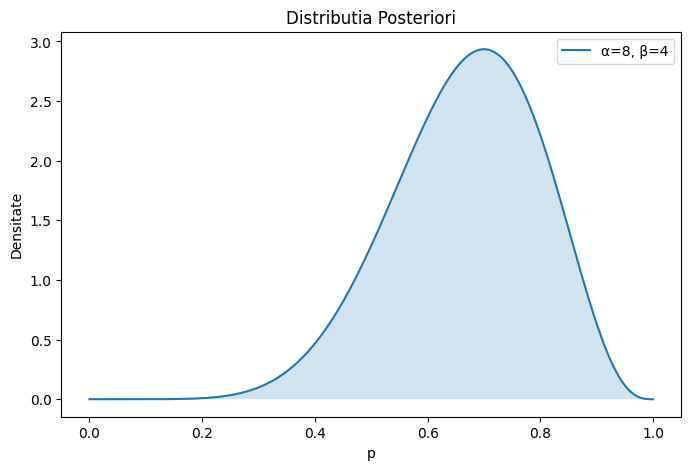

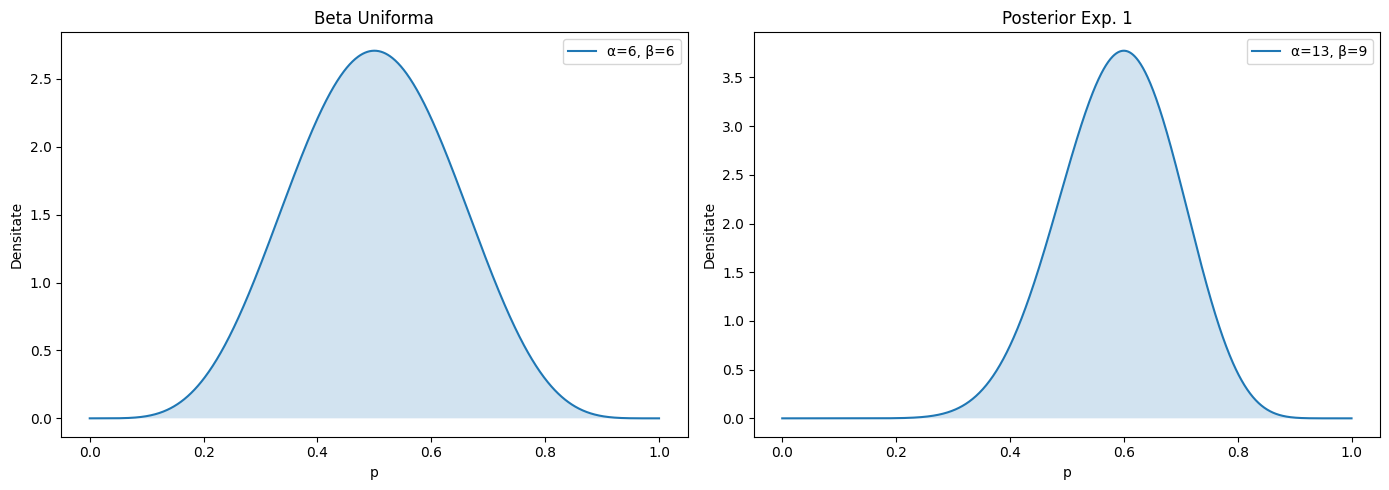

Parametri Posteriori:
α = 8, β = 4
Parametri Posteriori (Experiment 2 - Uniforma):
α = 6, β = 6
Parametri Posteriori (Experiment 2 - Exp. 1 ca Prior):
α = 13, β = 9


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def actualizeaza_parametri(alpha_init, beta_init, succes, esec):
    return alpha_init + succes, beta_init + esec

def ploteaza_distributie(alpha, beta_val, titlu, ax):
    p = np.linspace(0, 1, 1000)
    densitate = beta.pdf(p, alpha, beta_val)
    ax.plot(p, densitate, label=f'α={alpha}, β={beta_val}')
    ax.fill_between(p, densitate, alpha=0.2)
    ax.set_title(titlu)
    ax.set_xlabel('p')
    ax.set_ylabel('Densitate')
    ax.legend()

valori_1 = ['s', 's', 'b', 'b', 's', 's', 's', 's', 'b', 's']
succes_1 = valori_1.count('s')
esec_1 = valori_1.count('b')

prior_alpha = 1
prior_beta = 1

posterior_alpha_1, posterior_beta_1 = actualizeaza_parametri(prior_alpha, prior_beta, succes_1, esec_1)

figura, ax = plt.subplots(figsize=(8, 5))
ploteaza_distributie(posterior_alpha_1, posterior_beta_1, "Distributia Posteriori", ax)
plt.show()

valori_2 = ['b', 'b', 's', 'b', 's', 's', 'b', 's', 's', 'b']
succes_2 = valori_2.count('s')
esec_2 = valori_2.count('b')

posterior_alpha_2a, posterior_beta_2a = actualizeaza_parametri(prior_alpha, prior_beta, succes_2, esec_2)
posterior_alpha_2b, posterior_beta_2b = actualizeaza_parametri(posterior_alpha_1, posterior_beta_1, succes_2, esec_2)

figura, axs = plt.subplots(1, 2, figsize=(14, 5))
ploteaza_distributie(posterior_alpha_2a, posterior_beta_2a, "Beta Uniforma", axs[0])
ploteaza_distributie(posterior_alpha_2b, posterior_beta_2b, "Posterior Exp. 1", axs[1])
plt.tight_layout()
plt.show()

print("Parametri Posteriori:")
print(f"α = {posterior_alpha_1}, β = {posterior_beta_1}")
print("Parametri Posteriori (Experiment 2 - Uniforma):")
print(f"α = {posterior_alpha_2a}, β = {posterior_beta_2a}")
print("Parametri Posteriori (Experiment 2 - Exp. 1 ca Prior):")
print(f"α = {posterior_alpha_2b}, β = {posterior_beta_2b}")